# Vektordatenbanken – Explorative Analyse des OpenAlex-Korpus

Dieses Notebook dient der Vorbereitung eines Surveys zum aktuellen Forschungsstand rund um **Vektordatenbanken**.
Datengrundlage ist eine lokale Postgres-Datenbank mit 3999 aus OpenAlex importierten wissenschaftlichen Arbeiten.

**Analysekorpus:** Alle folgenden Auswertungen basieren nicht mehr auf allen 3999 Arbeiten, sondern auf einer
gezielt gefilterten Teilmenge — der Postgres-View `vektordb_corpus`. Diese enthält nur Arbeiten, die

- vom Typ `article` sind,
- deren **primäres Topic** (höchster Score in `work_topic`) im Field **Computer Science** liegt, und
- in deren Titel **oder** Abstract eine der Schreibweisen *vector database*, *vector-db*, *vector db*,
  *vectordb*, *vectordatabase*, *vektordatenbank*, *vektor-db*, *vektor db* vorkommt — umgesetzt über
  Postgres' Volltextsuche (`to_tsvector`/`to_tsquery`) inkl. Stemming, damit z. B. auch *databases*
  (Plural) erfasst wird.

Ziel ist es, statt alle Arbeiten einzeln zu lesen, diesen präzise abgegrenzten Korpus quantitativ zu erschließen:

1. Überblick über den Analysekorpus
2. Fachliche Feingliederung innerhalb Computer Science (Subfield/Topic, Zeitverlauf)
3. Zitations- und Keyword-Analyse
4. Geografische Verteilung, Institutionen, Kooperation, Förderung, Publikationsorgane
5. Cross-Domain-Analyse zur Identifikation von Anwendungsbereichen
6. Ableitung möglicher **Forschungslücken**
7. Ergänzende Textanalyse auf Abstract-Ebene

Die Ergebnisse dieses Notebooks sollen als Landkarte dienen, um gezielt Teilbereiche für die vertiefte Literaturarbeit auszuwählen.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from database.scripts.config import load_config
from database.scripts.connect import connect

import warnings

warnings.filterwarnings("ignore")

# DB-Konfiguration laden und Verbindung aufbauen
config = load_config("database/scripts/database.ini")
conn = connect(config)

# Schema setzen, damit Tabellen ohne "openalex."-Prefix angesprochen werden koennen
with conn.cursor() as cur:
    cur.execute("SET search_path TO openalex, public;")
conn.commit()

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

Connected to the PostgreSQL server.


### 0.1 Analysekorpus als View anlegen

Zwei Bausteine werden hier (idempotent, per `CREATE OR REPLACE`) in der Datenbank angelegt:

1. `reconstruct_abstract(jsonb)` — rekonstruiert aus OpenAlex' invertiertem Abstract-Index den
   lesbaren Volltext (wird fuer die Volltextsuche in Titel + Abstract benoetigt).
2. Die View `vektordb_corpus` — kapselt die oben beschriebene Filterlogik an einer zentralen Stelle,
   sodass alle folgenden Abfragen einfach per `JOIN vektordb_corpus vc ON vc.id = w.id` darauf filtern
   koennen, statt die Filterlogik in jeder Query zu wiederholen.

In [75]:
with conn.cursor() as cur:
    cur.execute("""
        CREATE OR REPLACE FUNCTION openalex.reconstruct_abstract(inv jsonb)
        RETURNS text AS $$
            SELECT CASE
                WHEN inv IS NULL OR jsonb_typeof(inv) <> 'object' THEN NULL
                ELSE (
                    SELECT string_agg(word, ' ' ORDER BY pos::int)
                    FROM jsonb_each(inv) AS kv(word, positions)
                    CROSS JOIN LATERAL jsonb_array_elements_text(kv.positions) AS pos
                )
            END
        $$ LANGUAGE sql IMMUTABLE;
    """)

    cur.execute("""
        CREATE OR REPLACE VIEW openalex.vektordb_corpus AS
        WITH abstract_text AS (
            SELECT w.id, openalex.reconstruct_abstract(w.abstract_inverted_index) AS abstract_plain
            FROM openalex.work w
        ),
        primary_topic AS (
            SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id
            FROM openalex.work_topic wt
            ORDER BY wt.work_id, wt.score DESC
        )
        SELECT w.id
        FROM openalex.work w
        JOIN abstract_text at ON at.id = w.id
        JOIN primary_topic pt ON pt.work_id = w.id
        JOIN openalex.topic t ON pt.topic_id = t.id
        JOIN openalex.subfield sf ON t.subfield_id = sf.id
        JOIN openalex.field f ON sf.field_id = f.id
        WHERE w.type_id = 'article'
          AND f.display_name = 'Computer Science'
          AND to_tsvector('english', COALESCE(w.title, '') || ' ' || COALESCE(at.abstract_plain, ''))
              @@ to_tsquery('english',
                  'vector <-> database | vector <-> db | vektor <-> db '
                  '| vectordatabase | vectordb | vektordatenbank');
    """)
conn.commit()

with conn.cursor() as cur:
    cur.execute("SELECT COUNT(*) FROM vektordb_corpus;")
    anzahl_korpus = cur.fetchone()[0]

print(f"Analysekorpus (View vektordb_corpus): {anzahl_korpus} Arbeiten")

Analysekorpus (View vektordb_corpus): 484 Arbeiten


**Hinweis zu `w.type_id = 'article'`:** Dieser Vergleich setzt voraus, dass in `work_type.id`
tatsächlich der Wert `'article'` steht (nicht nur in `display_description`). Falls die Kontrollabfrage
unten einen anderen Wert zeigt, muss die View entsprechend angepasst werden.

In [76]:
df_worktype_check = pd.read_sql("SELECT id, display_description FROM work_type ORDER BY id;", conn)
df_worktype_check

,id,display_description
0,article,"Original, citable research usually in a journal, including full research papers, brief communications, technical not..."
1,book-chapter,"A single chapter or section within a book, such as a contributed chapter in an edited volume, sometimes presenting o..."
2,editorial,"A piece expressing the views of an individual, group, or organization on a broad topic rather than on one specific w..."
3,letter,"A short message sent by readers to a journal's editor responding to previously published material, such as a letter ..."
4,other,"A catch-all for works that fit no other type, such as news items, obituaries, full journal issues, and non-scholarly..."
5,preprint,"An article whose primary location is a preprint repository such as arXiv, bioRxiv, medRxiv, SSRN, or Research Square."
6,review,"A journal article that summarizes and evaluates the existing research on a topic without reporting new findings, suc..."


## 1. Überblick über den Analysekorpus

Kennzahlen zum gefilterten Korpus: Anzahl der Arbeiten, abgedeckter Zeitraum, durchschnittliche
Zitationshäufigkeit sowie Open-Access-Anteil. Da die View bereits auf `type = article` einschränkt,
entfällt eine gesonderte Publikationstyp-Verteilung (wäre trivial 100 % Article).

In [77]:
query_overview = """
SELECT COUNT(*) AS anzahl_arbeiten,
       MIN(publication_year) AS erstes_jahr,
       MAX(publication_year) AS letztes_jahr,
       ROUND(AVG(cited_by_count), 2) AS avg_zitationen,
       SUM(CASE WHEN is_open_access THEN 1 ELSE 0 END) AS anzahl_open_access,
       SUM(CASE WHEN is_retracted THEN 1 ELSE 0 END) AS anzahl_retracted
FROM work w
JOIN vektordb_corpus vc ON vc.id = w.id;
"""

df_overview = pd.read_sql(query_overview, conn)
df_overview

,anzahl_arbeiten,erstes_jahr,letztes_jahr,avg_zitationen,anzahl_open_access,anzahl_retracted
0,484,1996,2026,2.44,370,0


### 1.1 Publikationen pro Jahr

Die zeitliche Entwicklung der Publikationszahlen im Analysekorpus zeigt, wie sich das
Forschungsinteresse an Vektordatenbanken über die Jahre entwickelt hat (z. B. sprunghafter Anstieg im
Zuge von Retrieval-Augmented-Generation / LLM-Anwendungen ab ca. 2022/2023).

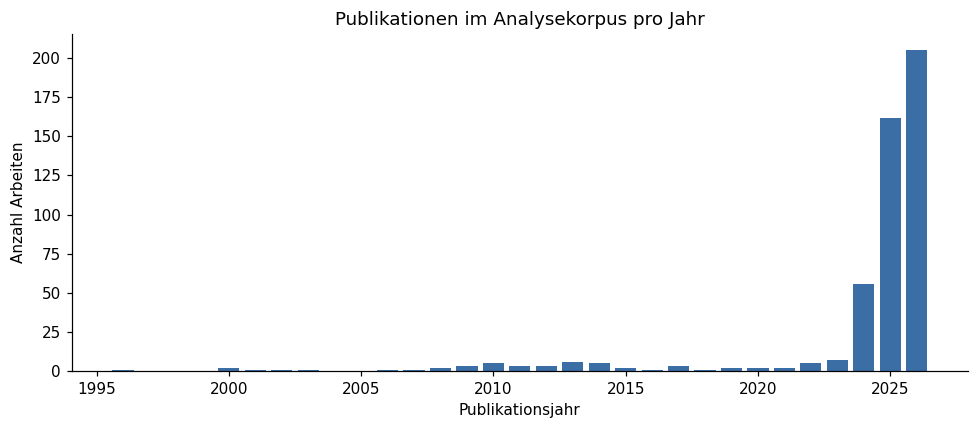

,publication_year,anzahl_arbeiten
0,1996,1
1,2000,2
2,2001,1
3,2002,1
4,2003,1
5,2006,1
6,2007,1
7,2008,2
8,2009,3
9,2010,5


In [78]:
query_per_year = """
SELECT publication_year, COUNT(*) AS anzahl_arbeiten
FROM work w
JOIN vektordb_corpus vc ON vc.id = w.id
WHERE publication_year IS NOT NULL
GROUP BY publication_year
ORDER BY publication_year;
"""

df_per_year = pd.read_sql(query_per_year, conn)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_per_year["publication_year"], df_per_year["anzahl_arbeiten"], color="#3b6ea5")
ax.set_xlabel("Publikationsjahr")
ax.set_ylabel("Anzahl Arbeiten")
ax.set_title("Publikationen im Analysekorpus pro Jahr")
plt.tight_layout()
plt.show()

df_per_year

### 1.2 Sprache und Open Access

In [79]:
query_language = """
SELECT COALESCE(l.display_name, 'unbekannt') AS sprache, COUNT(*) AS anzahl
FROM work w
JOIN vektordb_corpus vc ON vc.id = w.id
LEFT JOIN languages l ON w.language_code_alpha_2_3 = l.code_alpha_2_3
GROUP BY sprache
ORDER BY anzahl DESC
LIMIT 10;
"""

df_language = pd.read_sql(query_language, conn)
df_language

,sprache,anzahl
0,English,302
1,unbekannt,174
2,Indonesian,2
3,Portuguese,1
4,Spanish,1
5,Ukrainian,1
6,Old English (ca. 450-1100),1
7,German,1
8,Chinese,1


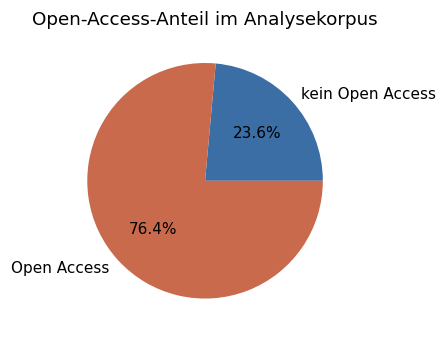

,is_open_access,anzahl,anteil_prozent
0,False,114,23.6
1,True,370,76.4


In [80]:
query_oa = """
SELECT is_open_access, COUNT(*) AS anzahl,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS anteil_prozent
FROM work w
JOIN vektordb_corpus vc ON vc.id = w.id
GROUP BY is_open_access;
"""

df_oa = pd.read_sql(query_oa, conn)

fig, ax = plt.subplots(figsize=(4, 4))
labels = df_oa["is_open_access"].map({True: "Open Access", False: "kein Open Access"}).fillna("unbekannt")
ax.pie(df_oa["anzahl"], labels=labels, autopct="%1.1f%%", colors=["#3b6ea5", "#c96a4d"])
ax.set_title("Open-Access-Anteil im Analysekorpus")
plt.tight_layout()
plt.show()

df_oa

## 2. Fachliche Feingliederung innerhalb Computer Science

Da `vektordb_corpus` bereits per Definition auf primäres Topic im Field **Computer Science**
eingeschränkt ist, wäre eine Domain- oder Field-Verteilung trivial (100 % Computer Science). Sinnvoll
ist stattdessen die Feingliederung eine Ebene tiefer: **Subfield** und **Topic** innerhalb von CS.

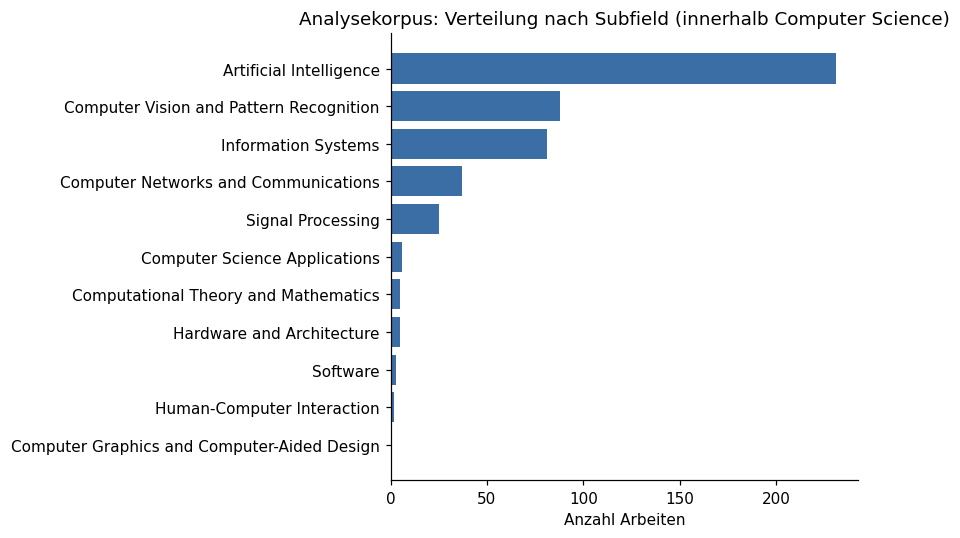

,subfield,anzahl_arbeiten
0,Artificial Intelligence,231
1,Computer Vision and Pattern Recognition,88
2,Information Systems,81
3,Computer Networks and Communications,37
4,Signal Processing,25
5,Computer Science Applications,6
6,Computational Theory and Mathematics,5
7,Hardware and Architecture,5
8,Software,3
9,Human-Computer Interaction,2


In [81]:
query_subfield = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
)
SELECT sf.display_name AS subfield, COUNT(*) AS anzahl_arbeiten
FROM vektordb_corpus vc
JOIN primary_topic pt ON pt.work_id = vc.id
JOIN topic t ON pt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
GROUP BY sf.display_name
ORDER BY anzahl_arbeiten DESC;
"""

df_subfield = pd.read_sql(query_subfield, conn)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_subfield["subfield"], df_subfield["anzahl_arbeiten"], color="#3b6ea5")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Analysekorpus: Verteilung nach Subfield (innerhalb Computer Science)")
plt.tight_layout()
plt.show()

df_subfield

### 2.1 Top-Topics im Analysekorpus

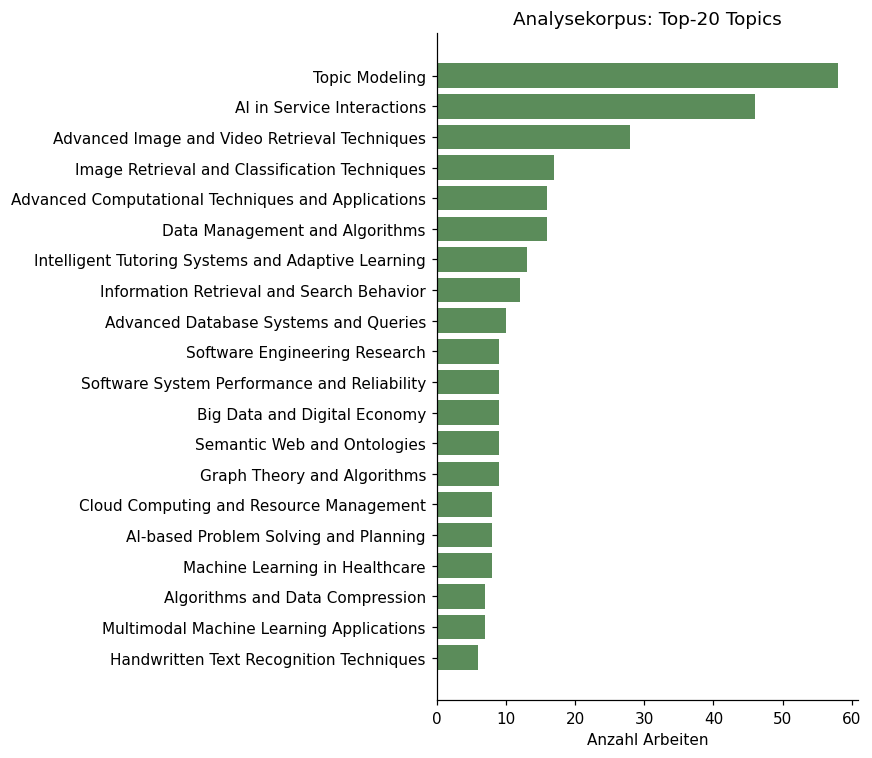

,topic,anzahl_arbeiten
0,Topic Modeling,58
1,AI in Service Interactions,46
2,Advanced Image and Video Retrieval Techniques,28
3,Image Retrieval and Classification Techniques,17
4,Advanced Computational Techniques and Applications,16
5,Data Management and Algorithms,16
6,Intelligent Tutoring Systems and Adaptive Learning,13
7,Information Retrieval and Search Behavior,12
8,Advanced Database Systems and Queries,10
9,Software Engineering Research,9


In [82]:
query_topic = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
)
SELECT t.display_name AS topic, COUNT(*) AS anzahl_arbeiten
FROM vektordb_corpus vc
JOIN primary_topic pt ON pt.work_id = vc.id
JOIN topic t ON pt.topic_id = t.id
GROUP BY t.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 20;
"""

df_topic = pd.read_sql(query_topic, conn)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(df_topic["topic"], df_topic["anzahl_arbeiten"], color="#5b8c5a")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Analysekorpus: Top-20 Topics")
plt.tight_layout()
plt.show()

df_topic

### 2.2 Zeitliche Entwicklung der Top-Topics

Anzahl Publikationen je Top-10-Topic und Jahr als Heatmap — zeigt, welche Teilgebiete innerhalb des
Analysekorpus aktuell an Bedeutung gewinnen bzw. eher stabil/etabliert sind.

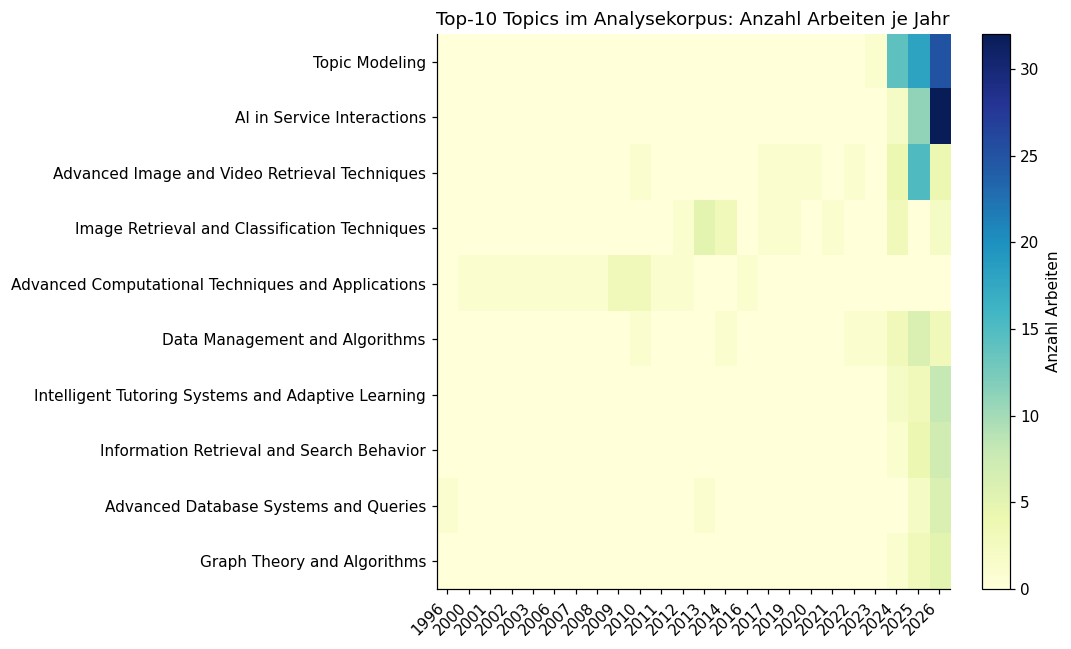

publication_year,1996,2000,2001,2002,2003,2006,2007,2008,2009,2010,...,2016,2017,2019,2020,2021,2022,2023,2024,2025,2026
topic,,,,,,,,,,,,,,,,,,,,,
Topic Modeling,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14.0,18.0,25.0
AI in Service Interactions,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,11.0,32.0
Advanced Image and Video Retrieval Techniques,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,4.0,15.0,4.0
Image Retrieval and Classification Techniques,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,0.0,2.0
Advanced Computational Techniques and Applications,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Data Management and Algorithms,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,6.0,3.0
Intelligent Tutoring Systems and Adaptive Learning,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,8.0
Information Retrieval and Search Behavior,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,7.0
Advanced Database Systems and Queries,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,6.0


In [83]:
query_topic_year = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
corpus_topic_work AS (
    SELECT pt.work_id, t.display_name AS topic
    FROM vektordb_corpus vc
    JOIN primary_topic pt ON pt.work_id = vc.id
    JOIN topic t ON pt.topic_id = t.id
),
top_topics AS (
    SELECT topic FROM corpus_topic_work GROUP BY topic ORDER BY COUNT(*) DESC LIMIT 10
)
SELECT ctw.topic, w.publication_year, COUNT(*) AS anzahl
FROM corpus_topic_work ctw
JOIN work w ON ctw.work_id = w.id
WHERE ctw.topic IN (SELECT topic FROM top_topics)
  AND w.publication_year IS NOT NULL
GROUP BY ctw.topic, w.publication_year
ORDER BY w.publication_year;
"""

df_topic_year = pd.read_sql(query_topic_year, conn)

pivot = df_topic_year.pivot_table(index="topic", columns="publication_year",
                                   values="anzahl", fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Top-10 Topics im Analysekorpus: Anzahl Arbeiten je Jahr")
fig.colorbar(im, ax=ax, label="Anzahl Arbeiten")
plt.tight_layout()
plt.show()

pivot

## 3. Zitations- und Keyword-Analyse

Die meistzitierten Arbeiten im Analysekorpus sind gute Kandidaten für die "Kernliteratur" des
Surveys. Ergänzend zeigt die Ø-Zitationshäufigkeit je Topic, welche Teilgebiete bereits stark
rezipiert werden, und die häufigsten Keywords liefern zusätzliches Vokabular für die Literatursuche.

**Hinweis:** Die `HAVING COUNT(*) >= n`-Schwellen in den folgenden Abfragen sind bewusst niedrig
gewählt, da der Analysekorpus (`vektordb_corpus`) deutlich kleiner ist als der Gesamtdatensatz —
je nach tatsächlicher Korpusgröße ggf. anpassen.

In [84]:
query_top_cited = """
SELECT title, publication_year, cited_by_count, doi
FROM work w
JOIN vektordb_corpus vc ON vc.id = w.id
ORDER BY cited_by_count DESC NULLS LAST
LIMIT 15;
"""

df_top_cited = pd.read_sql(query_top_cited, conn)
df_top_cited

,title,publication_year,cited_by_count,doi
0,Approximate Nearest Neighbor Search by Residual Vector Quantization,2010,162,https://doi.org/10.3390/s101211259
1,Survey of vector database management systems,2024,102,https://doi.org/10.1007/s00778-024-00864-x
2,"Vector database management systems: Fundamental concepts, use-cases, and current challenges",2024,77,https://doi.org/10.1016/j.cogsys.2024.101216
3,Manu,2022,71,https://doi.org/10.14778/3554821.3554843
4,Analysis of Adaptive Image Retrieval by Transition Kalman Filter Approach based on Intensity Parameter,2021,55,https://doi.org/10.36548/jiip.2021.1.002
5,"A Novel Collaborative SRU Network With Dynamic Behaviour Aggregation, Reduced Communication Overhead and Explainable...",2024,53,https://doi.org/10.1109/jbhi.2024.3352013
6,Vectorizing Database Column Scans with Complex Predicates,2013,47,NaN
7,Starling: An I/O-Efficient Disk-Resident Graph Index Framework for High-Dimensional Vector Similarity Search on Data...,2024,40,https://doi.org/10.1145/3639269
8,The Term Vector Database: fast access to indexing terms for Web pages,2000,39,https://doi.org/10.1016/s1389-1286(00)00046-3
9,"Emotion-Aware Embedding Fusion in Large Language Models (Flan-T5, Llama 2, DeepSeek-R1, and ChatGPT 4) for Intellige...",2025,35,https://doi.org/10.3390/ai6030056


In [85]:
query_avg_cited_topic = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
corpus_topic_work AS (
    SELECT pt.work_id, t.display_name AS topic
    FROM vektordb_corpus vc
    JOIN primary_topic pt ON pt.work_id = vc.id
    JOIN topic t ON pt.topic_id = t.id
)
SELECT ctw.topic,
       COUNT(*) AS anzahl_arbeiten,
       ROUND(AVG(w.cited_by_count), 1) AS avg_zitationen
FROM corpus_topic_work ctw
JOIN work w ON ctw.work_id = w.id
GROUP BY ctw.topic
HAVING COUNT(*) >= 3
ORDER BY avg_zitationen DESC
LIMIT 20;
"""

df_avg_cited_topic = pd.read_sql(query_avg_cited_topic, conn)
df_avg_cited_topic

,topic,anzahl_arbeiten,avg_zitationen
0,Caching and Content Delivery,3,23.7
1,Algorithms and Data Compression,7,16.6
2,Web Data Mining and Analysis,3,14.3
3,Advanced Image and Video Retrieval Techniques,28,9.8
4,Face recognition and analysis,5,7.6
5,Data Mining Algorithms and Applications,4,6.5
6,Image Retrieval and Classification Techniques,17,6.3
7,Data Management and Algorithms,16,5.6
8,Advanced Database Systems and Queries,10,4.9
9,Cloud Computing and Resource Management,8,3.1


### 3.1 Häufigste Keywords im Analysekorpus

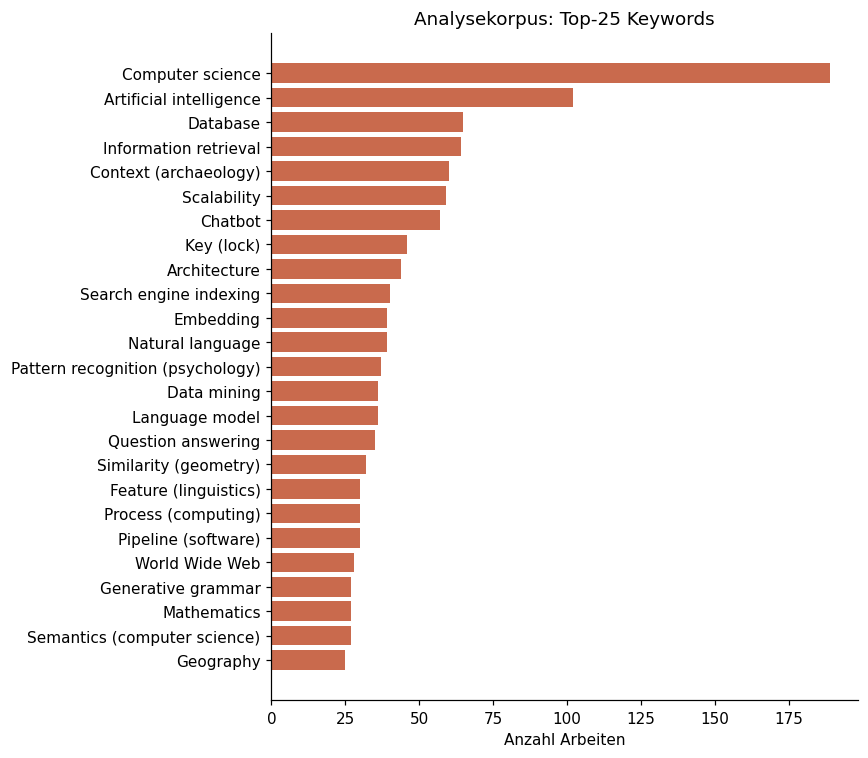

,keyword,anzahl,avg_score
0,Computer science,189,0.629
1,Artificial intelligence,102,0.386
2,Database,65,0.504
3,Information retrieval,64,0.444
4,Context (archaeology),60,0.514
5,Scalability,59,0.568
6,Chatbot,57,0.738
7,Key (lock),46,0.464
8,Architecture,44,0.456
9,Search engine indexing,40,0.612


In [86]:
query_keywords = """
SELECT k.display_name AS keyword, COUNT(*) AS anzahl, ROUND(AVG(wk.score)::numeric, 3) AS avg_score
FROM work_keyword wk
JOIN vektordb_corpus vc ON vc.id = wk.work_id
JOIN keyword k ON wk.keyword_id = k.id
GROUP BY k.display_name
ORDER BY anzahl DESC
LIMIT 25;
"""

df_keywords = pd.read_sql(query_keywords, conn)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(df_keywords["keyword"], df_keywords["anzahl"], color="#c96a4d")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Analysekorpus: Top-25 Keywords")
plt.tight_layout()
plt.show()

df_keywords

## 4. Geografische Verteilung, Institutionen und Kooperation

Diese Auswertungen zeigen, welche Länder und Institutionen die Forschung im Analysekorpus treiben
und wie stark international kooperiert wird.

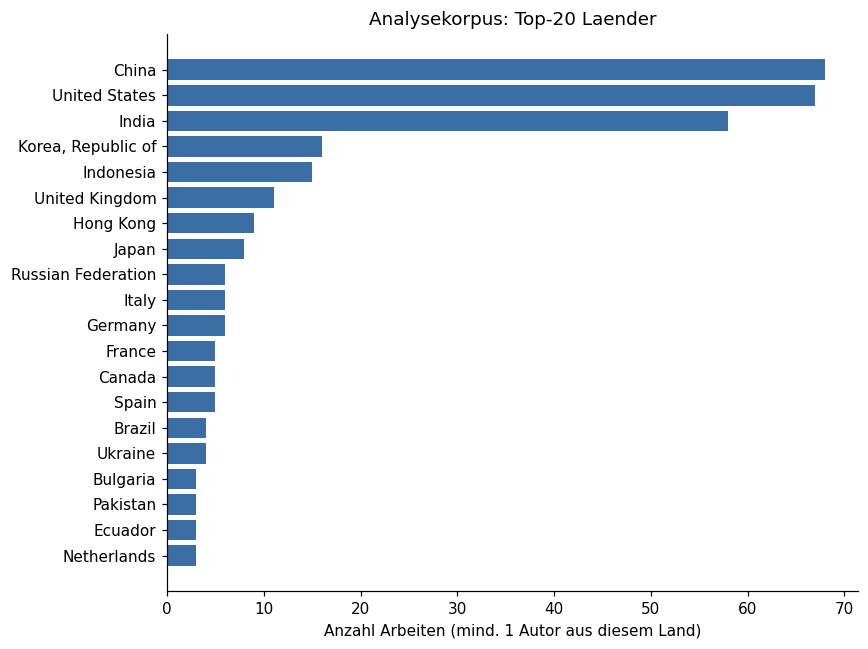

,land,anzahl_arbeiten
0,China,68
1,United States,67
2,India,58
3,"Korea, Republic of",16
4,Indonesia,15
5,United Kingdom,11
6,Hong Kong,9
7,Japan,8
8,Russian Federation,6
9,Italy,6


In [87]:
query_countries = """
SELECT c.display_name AS land, COUNT(DISTINCT wa.work_id) AS anzahl_arbeiten
FROM work_author wa
JOIN vektordb_corpus vc ON vc.id = wa.work_id
JOIN author_country ac ON wa.author_id = ac.author_id
JOIN country c ON ac.country_code_alpha_2 = c.code_alpha_2
GROUP BY c.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 20;
"""

df_countries = pd.read_sql(query_countries, conn)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_countries["land"], df_countries["anzahl_arbeiten"], color="#3b6ea5")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten (mind. 1 Autor aus diesem Land)")
ax.set_title("Analysekorpus: Top-20 Laender")
plt.tight_layout()
plt.show()

df_countries

In [88]:
query_institutions = """
SELECT i.display_name AS institution, COUNT(DISTINCT wai.work_id) AS anzahl_arbeiten
FROM work_author_institution wai
JOIN vektordb_corpus vc ON vc.id = wai.work_id
JOIN institution i ON wai.institution_id = i.id
GROUP BY i.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 15;
"""

df_institutions = pd.read_sql(query_institutions, conn)
df_institutions

,institution,anzahl_arbeiten
0,Tsinghua University,8
1,Hong Kong University of Science and Technology,4
2,Zhejiang University,4
3,East China Normal University,4
4,PSG INSTITUTE OF TECHNOLOGY AND APPLIED RESEARCH,4
5,Purdue University West Lafayette,4
6,Dr. Sarvepalli Radhakrishnan Rajasthan Ayurved University,3
7,Amazon (United States),3
8,Chinese Academy of Sciences,3
9,Beihang University,3


In [89]:
query_inst_type = """
SELECT COALESCE(it.display_name, 'unbekannt') AS institutionstyp,
       COUNT(DISTINCT i.id) AS anzahl_institutionen
FROM institution i
JOIN work_author_institution wai ON wai.institution_id = i.id
JOIN vektordb_corpus vc ON vc.id = wai.work_id
LEFT JOIN institution_type it ON i.institution_type_id = it.id
GROUP BY institutionstyp
ORDER BY anzahl_institutionen DESC;
"""

df_inst_type = pd.read_sql(query_inst_type, conn)
df_inst_type

,institutionstyp,anzahl_institutionen
0,education,295
1,company,44
2,facility,31
3,government,13
4,nonprofit,8
5,other,8
6,healthcare,8
7,archive,3
8,funder,1
9,unbekannt,1


### 4.1 Internationale Kooperation im Zeitverlauf

Anteil der Arbeiten pro Jahr, deren Autor:innen aus mehr als einem Land stammen.

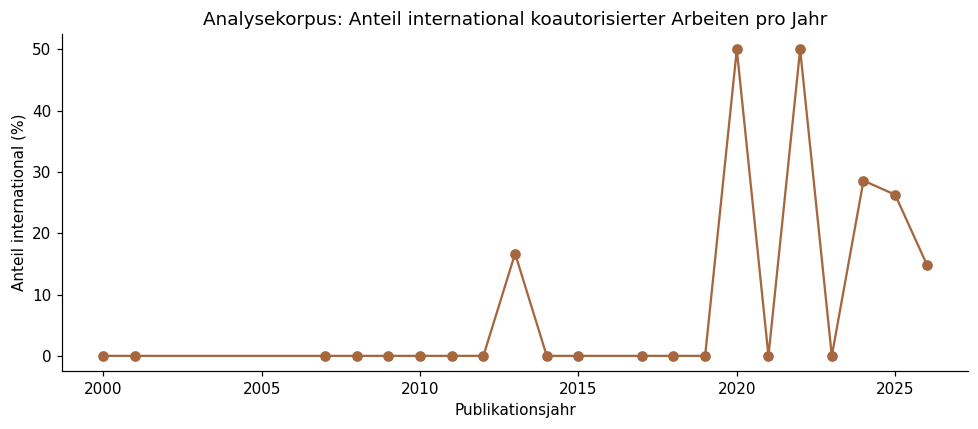

,publication_year,anzahl_arbeiten,anzahl_international,anteil_international_prozent
0,2000,1,0,0.0
1,2001,1,0,0.0
2,2007,1,0,0.0
3,2008,1,0,0.0
4,2009,1,0,0.0
5,2010,3,0,0.0
6,2011,1,0,0.0
7,2012,2,0,0.0
8,2013,6,1,16.7
9,2014,4,0,0.0


In [90]:
query_international = """
WITH work_countries AS (
    SELECT wa.work_id, COUNT(DISTINCT ac.country_code_alpha_2) AS anzahl_laender
    FROM work_author wa
    JOIN vektordb_corpus vc ON vc.id = wa.work_id
    JOIN author_country ac ON wa.author_id = ac.author_id
    GROUP BY wa.work_id
)
SELECT w.publication_year,
       COUNT(*) AS anzahl_arbeiten,
       SUM(CASE WHEN wc.anzahl_laender > 1 THEN 1 ELSE 0 END) AS anzahl_international,
       ROUND(100.0 * SUM(CASE WHEN wc.anzahl_laender > 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS anteil_international_prozent
FROM work w
JOIN work_countries wc ON w.id = wc.work_id
WHERE w.publication_year IS NOT NULL
GROUP BY w.publication_year
ORDER BY w.publication_year;
"""

df_international = pd.read_sql(query_international, conn)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_international["publication_year"], df_international["anteil_international_prozent"],
        marker="o", color="#a5673f")
ax.set_xlabel("Publikationsjahr")
ax.set_ylabel("Anteil international (%)")
ax.set_title("Analysekorpus: Anteil international koautorisierter Arbeiten pro Jahr")
plt.tight_layout()
plt.show()

df_international

### 4.2 Förderung und Publikationsorgane

In [91]:
query_funder = """
SELECT f.display_name AS funder, COUNT(DISTINCT wf.work_id) AS anzahl_arbeiten
FROM work_funder wf
JOIN vektordb_corpus vc ON vc.id = wf.work_id
JOIN funder f ON wf.funder_id = f.id
GROUP BY f.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 15;
"""

df_funder = pd.read_sql(query_funder, conn)
df_funder

,funder,anzahl_arbeiten
0,National Natural Science Foundation of China,12
1,National Key Research and Development Program of China,7
2,National Science Foundation,4
3,European Commission,3
4,Institute for Information and Communications Technology Promotion,2
5,Division of Human Resource Development,2
6,National Science and Technology Council,2
7,National Research Foundation of Korea,2
8,"Ministry of Science and ICT, South Korea",2
9,Iran Telecommunication Research Center,1


In [92]:
query_sources = """
SELECT s.display_name AS quelle, COALESCE(st.display_name, 'unbekannt') AS quelltyp,
       COUNT(DISTINCT wl.work_id) AS anzahl_arbeiten
FROM work_locations wl
JOIN vektordb_corpus vc ON vc.id = wl.work_id
JOIN locations l ON wl.locations_id = l.id
JOIN source s ON l.source_id = s.id
LEFT JOIN source_type st ON s.source_type_id = st.id
WHERE wl.is_primary = TRUE
GROUP BY s.display_name, quelltyp
ORDER BY anzahl_arbeiten DESC
LIMIT 15;
"""

df_sources = pd.read_sql(query_sources, conn)
df_sources

,quelle,quelltyp,anzahl_arbeiten
0,Zenodo (CERN European Organization for Nuclear Research),repository,64
1,INTERANTIONAL JOURNAL OF SCIENTIFIC RESEARCH IN ENGINEERING AND MANAGEMENT,journal,19
2,International Journal for Research in Applied Science and Engineering Technology,journal,18
3,Proceedings of the VLDB Endowment,journal,17
4,Proceedings of the ACM on Management of Data,journal,13
5,Applied Sciences,journal,11
6,Open MIND,repository,9
7,IEEE Access,journal,7
8,International Scientific Journal of Engineering and Management,journal,5
9,International Journal of Creative and Open Research in Engineering and Management,journal,4


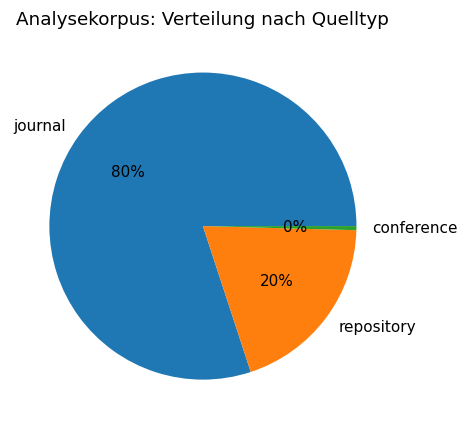

,quelltyp,anzahl_arbeiten
0,journal,373
1,repository,91
2,conference,2


In [93]:
query_source_type = """
SELECT COALESCE(st.display_name, 'unbekannt') AS quelltyp,
       COUNT(DISTINCT wl.work_id) AS anzahl_arbeiten
FROM work_locations wl
JOIN vektordb_corpus vc ON vc.id = wl.work_id
JOIN locations l ON wl.locations_id = l.id
LEFT JOIN source s ON l.source_id = s.id
LEFT JOIN source_type st ON s.source_type_id = st.id
WHERE wl.is_primary = TRUE
GROUP BY quelltyp
ORDER BY anzahl_arbeiten DESC;
"""

df_source_type = pd.read_sql(query_source_type, conn)

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(df_source_type["anzahl_arbeiten"], labels=df_source_type["quelltyp"], autopct="%1.0f%%")
ax.set_title("Analysekorpus: Verteilung nach Quelltyp")
plt.tight_layout()
plt.show()

df_source_type

## 5. Cross-Domain-Analyse: In welchen Bereichen werden Vektordatenbanken eingesetzt?

Jede Arbeit im Analysekorpus hat als *primäres* Topic bereits ein CS-Topic (per Definition der View).
Diese Analyse betrachtet zusätzlich die *sekundären* Topics dieser Arbeiten — also Topics aus anderen
Fields/Domains, die ebenfalls zugeordnet sind. Das macht sichtbar, in welchen Anwendungsdomänen
(z. B. Medizin, Biologie, Sozialwissenschaften) Vektordatenbank-Forschung eine Rolle spielt.

In [94]:
query_cross_domain = """
SELECT d.display_name AS anwendungsdomain, COUNT(DISTINCT wt.work_id) AS anzahl_arbeiten
FROM work_topic wt
JOIN vektordb_corpus vc ON vc.id = wt.work_id
JOIN topic t ON wt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
JOIN domain d ON f.domain_id = d.id
WHERE f.display_name != 'Computer Science'
GROUP BY d.display_name
ORDER BY anzahl_arbeiten DESC;
"""

df_cross_domain = pd.read_sql(query_cross_domain, conn)
df_cross_domain

,anwendungsdomain,anzahl_arbeiten
0,Social Sciences,91
1,Physical Sciences,42
2,Health Sciences,34
3,Life Sciences,20


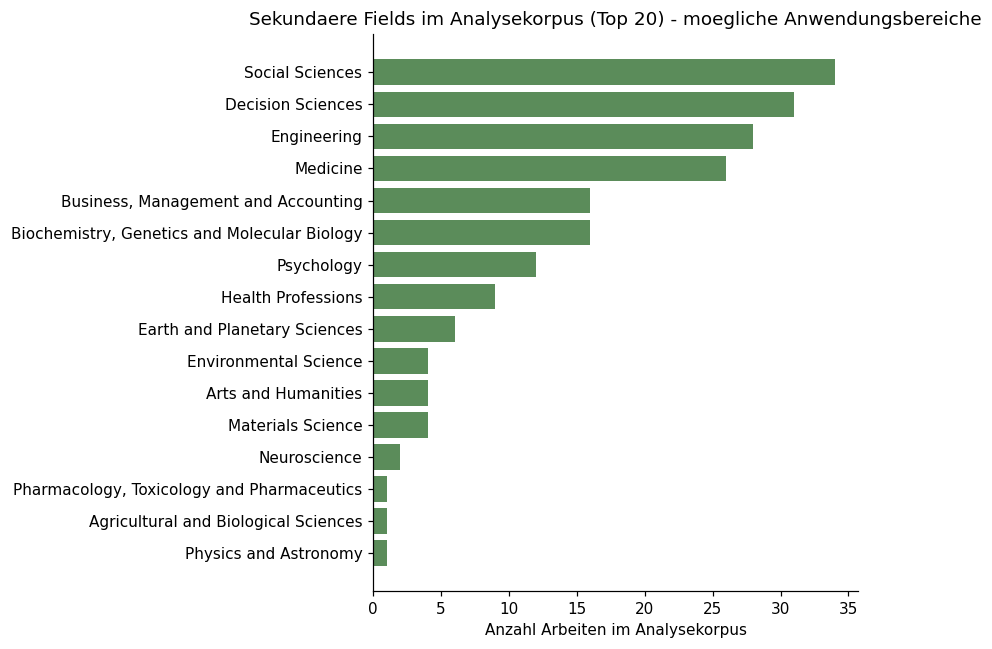

,anwendungsfield,anzahl_arbeiten
0,Social Sciences,34
1,Decision Sciences,31
2,Engineering,28
3,Medicine,26
4,"Business, Management and Accounting",16
5,"Biochemistry, Genetics and Molecular Biology",16
6,Psychology,12
7,Health Professions,9
8,Earth and Planetary Sciences,6
9,Environmental Science,4


In [95]:
query_cross_field = """
SELECT f.display_name AS anwendungsfield, COUNT(DISTINCT wt.work_id) AS anzahl_arbeiten
FROM work_topic wt
JOIN vektordb_corpus vc ON vc.id = wt.work_id
JOIN topic t ON wt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
WHERE f.display_name != 'Computer Science'
GROUP BY f.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 20;
"""

df_cross_field = pd.read_sql(query_cross_field, conn)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_cross_field["anwendungsfield"], df_cross_field["anzahl_arbeiten"], color="#5b8c5a")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten im Analysekorpus")
ax.set_title("Sekundaere Fields im Analysekorpus (Top 20) - moegliche Anwendungsbereiche")
plt.tight_layout()
plt.show()

df_cross_field

## 6. Identifikation möglicher Forschungslücken

Für jedes Topic im Analysekorpus wird die **Gesamtanzahl** der Arbeiten der **Recency**
(Anteil der Arbeiten aus den letzten 2 Jahren) gegenübergestellt.

- **Wenige Arbeiten insgesamt, aber hoher Recency-Anteil** → aufkommendes, noch wenig erschlossenes Thema
- **Viele Arbeiten insgesamt, niedriger Recency-Anteil** → etabliertes, eher gesättigtes Thema

**Hinweis:** `HAVING COUNT(*) >= 2` ist bewusst niedrig gewählt, da der gefilterte Korpus kleiner ist
als der Gesamtdatensatz — je nach tatsächlicher Korpusgröße ggf. anpassen.

In [96]:
query_gap = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
corpus_topic_work AS (
    SELECT pt.work_id, t.display_name AS topic, w.publication_year
    FROM vektordb_corpus vc
    JOIN primary_topic pt ON pt.work_id = vc.id
    JOIN topic t ON pt.topic_id = t.id
    JOIN work w ON pt.work_id = w.id
),
max_year AS (
    SELECT MAX(publication_year) AS letztes_jahr FROM work
)
SELECT topic,
       COUNT(*) AS anzahl_gesamt,
       SUM(CASE WHEN publication_year >= (SELECT letztes_jahr FROM max_year) - 1
                THEN 1 ELSE 0 END) AS anzahl_letzte_2_jahre,
       ROUND(100.0 * SUM(CASE WHEN publication_year >= (SELECT letztes_jahr FROM max_year) - 1
                               THEN 1 ELSE 0 END) / COUNT(*), 1) AS anteil_letzte_2_jahre_prozent
FROM corpus_topic_work
GROUP BY topic
HAVING COUNT(*) >= 2
ORDER BY anteil_letzte_2_jahre_prozent DESC, anzahl_gesamt ASC;
"""

df_gap = pd.read_sql(query_gap, conn)
df_gap.head(20)

,topic,anzahl_gesamt,anzahl_letzte_2_jahre,anteil_letzte_2_jahre_prozent
0,Generative Adversarial Networks and Image Synthesis,2,2,100.0
1,Scientific Research and Philosophical Inquiry,2,2,100.0
2,Adversarial Robustness in Machine Learning,2,2,100.0
3,Network Security and Intrusion Detection,2,2,100.0
4,Artificial Intelligence in Games,2,2,100.0
5,Augmented Reality Applications,2,2,100.0
6,"Mathematics, Computing, and Information Processing",2,2,100.0
7,Cognitive Computing and Networks,2,2,100.0
8,Context-Aware Activity Recognition Systems,2,2,100.0
9,Cybersecurity and Information Systems,2,2,100.0


Da `anzahl_gesamt` stark rechtsschief verteilt sein kann und eine reine Punktwolke mit vielen
Beschriftungen schnell unleserlich wird, folgt die Quadrantenansicht mit **logarithmischer X-Achse**
und farblich hinterlegten Quadranten. Die Top-10-Kandidaten (nach *Gap-Score* = Recency-Anteil /
Anzahl Arbeiten) werden nur **nummeriert**, die Zuordnung Nummer → Topic-Name steht in der Tabelle
direkt darunter — das vermeidet überlappende Text-Labels bei eng beieinander liegenden Punkten.

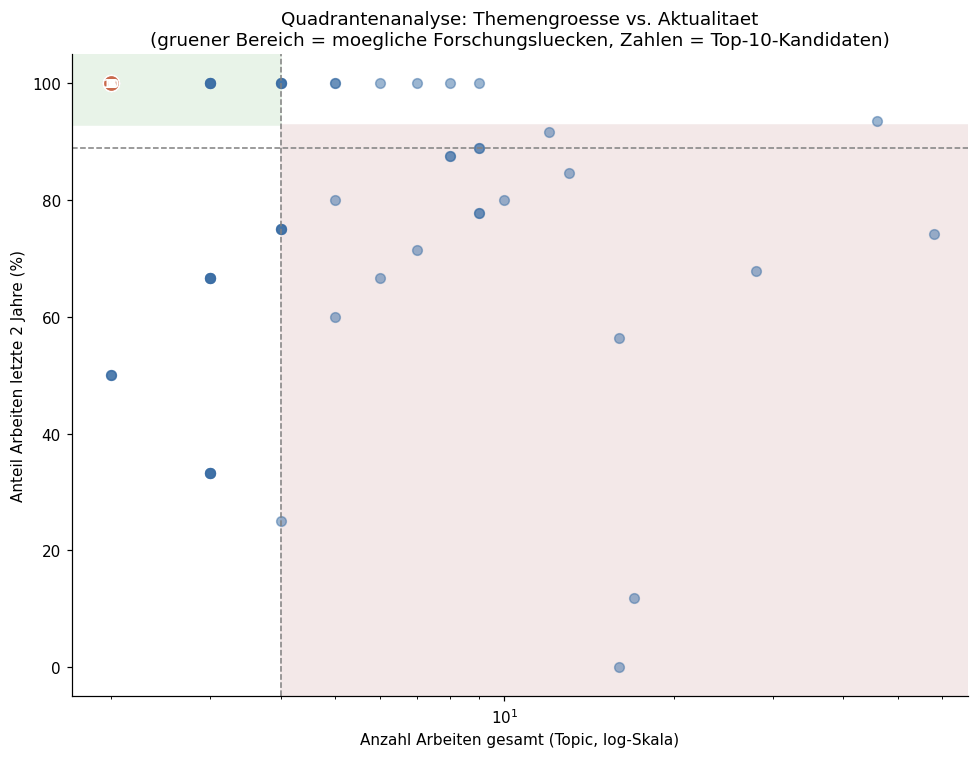

,topic,anzahl_gesamt,anteil_letzte_2_jahre_prozent,gap_score
1,Generative Adversarial Networks and Image Synthesis,2,100.0,50.0
2,Scientific Research and Philosophical Inquiry,2,100.0,50.0
3,Adversarial Robustness in Machine Learning,2,100.0,50.0
4,Network Security and Intrusion Detection,2,100.0,50.0
5,Artificial Intelligence in Games,2,100.0,50.0
6,Augmented Reality Applications,2,100.0,50.0
7,"Mathematics, Computing, and Information Processing",2,100.0,50.0
8,Cognitive Computing and Networks,2,100.0,50.0
9,Context-Aware Activity Recognition Systems,2,100.0,50.0
10,Cybersecurity and Information Systems,2,100.0,50.0


In [97]:
fig, ax = plt.subplots(figsize=(9, 7))

median_x = df_gap["anzahl_gesamt"].median()
median_y = df_gap["anteil_letzte_2_jahre_prozent"].median()
xmin = df_gap["anzahl_gesamt"].min() * 0.85
xmax = df_gap["anzahl_gesamt"].max() * 1.15

ax.axvspan(xmin, median_x, ymin=median_y / 100, ymax=1, color="#e8f3e8", zorder=0)
ax.axvspan(median_x, xmax, ymin=0, ymax=median_y / 100, color="#f3e8e8", zorder=0)

ax.scatter(df_gap["anzahl_gesamt"], df_gap["anteil_letzte_2_jahre_prozent"],
           s=40, color="#3b6ea5", alpha=0.5, zorder=2)

ax.axvline(median_x, color="grey", linestyle="--", linewidth=1)
ax.axhline(median_y, color="grey", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlim(xmin, xmax)

gap_candidates = df_gap[(df_gap["anzahl_gesamt"] <= median_x) &
                         (df_gap["anteil_letzte_2_jahre_prozent"] >= median_y)].copy()
gap_candidates["gap_score"] = (gap_candidates["anteil_letzte_2_jahre_prozent"]
                                / gap_candidates["anzahl_gesamt"])

top_labels = gap_candidates.sort_values("gap_score", ascending=False).head(10).reset_index(drop=True)
top_labels.index = top_labels.index + 1

ax.scatter(top_labels["anzahl_gesamt"], top_labels["anteil_letzte_2_jahre_prozent"],
           s=110, color="#c96a4d", edgecolor="white", linewidth=0.8, zorder=3)

for nr, row in top_labels.iterrows():
    ax.annotate(str(nr), (row["anzahl_gesamt"], row["anteil_letzte_2_jahre_prozent"]),
                fontsize=8, fontweight="bold", color="white",
                ha="center", va="center", zorder=4)

ax.set_xlabel("Anzahl Arbeiten gesamt (Topic, log-Skala)")
ax.set_ylabel("Anteil Arbeiten letzte 2 Jahre (%)")
ax.set_title("Quadrantenanalyse: Themengroesse vs. Aktualitaet\n(gruener Bereich = moegliche Forschungsluecken, Zahlen = Top-10-Kandidaten)")
plt.tight_layout()
plt.show()

top_labels[["topic", "anzahl_gesamt", "anteil_letzte_2_jahre_prozent", "gap_score"]]

### 6.1 Alternative Darstellung: Ranked-Bar-Chart der Gap-Kandidaten

Statt einer Punktwolke mit Beschriftungen zeigt dieses Balkendiagramm die Top-15-Gap-Kandidaten
sortiert nach Aktualitätsanteil, mit der jeweiligen Stichprobengröße (`n=`) als Zusatzinfo direkt
am Balken.

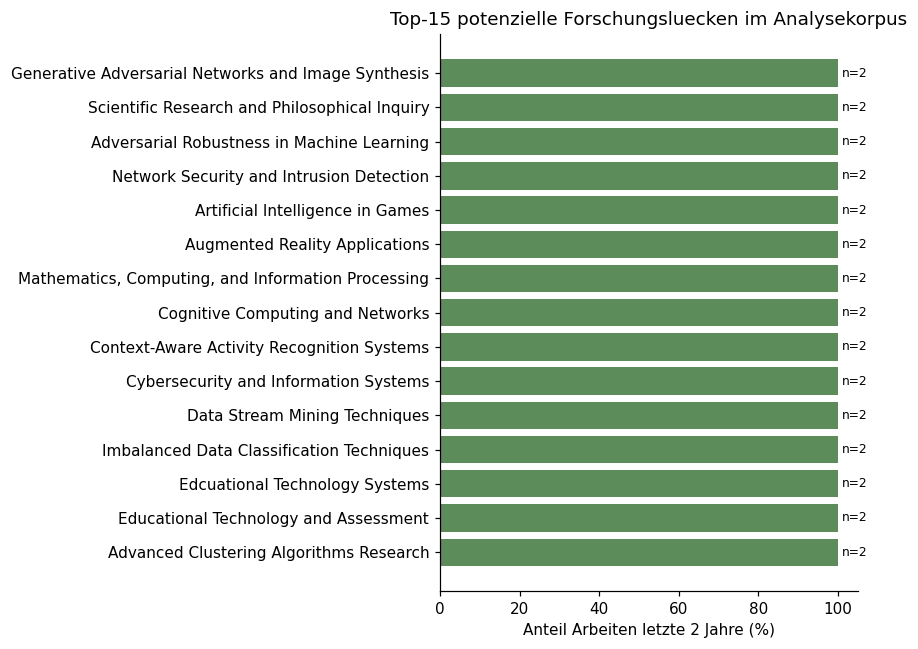

,topic,anzahl_gesamt,anteil_letzte_2_jahre_prozent,gap_score
0,Generative Adversarial Networks and Image Synthesis,2,100.0,50.0
1,Scientific Research and Philosophical Inquiry,2,100.0,50.0
2,Adversarial Robustness in Machine Learning,2,100.0,50.0
3,Network Security and Intrusion Detection,2,100.0,50.0
4,Artificial Intelligence in Games,2,100.0,50.0
5,Augmented Reality Applications,2,100.0,50.0
6,"Mathematics, Computing, and Information Processing",2,100.0,50.0
7,Cognitive Computing and Networks,2,100.0,50.0
8,Context-Aware Activity Recognition Systems,2,100.0,50.0
9,Cybersecurity and Information Systems,2,100.0,50.0


In [98]:
top_gap_bar = gap_candidates.sort_values("gap_score", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_gap_bar["topic"], top_gap_bar["anteil_letzte_2_jahre_prozent"], color="#5b8c5a")
ax.invert_yaxis()
for bar, n in zip(bars, top_gap_bar["anzahl_gesamt"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"n={n}",
            va="center", fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel("Anteil Arbeiten letzte 2 Jahre (%)")
ax.set_title("Top-15 potenzielle Forschungsluecken im Analysekorpus")
plt.tight_layout()
plt.show()

top_gap_bar[["topic", "anzahl_gesamt", "anteil_letzte_2_jahre_prozent", "gap_score"]]

## 7. Ergänzende Textanalyse auf Abstract-Ebene

Ergänzend zur Topic-/Keyword-Klassifikation ein Blick in die Abstracts des Analysekorpus selbst.
OpenAlex speichert Abstracts als *invertierten Index* (`{"wort": [Position1, Position2, ...], ...}`);
der folgende Code rekonstruiert daraus den lesbaren Text (mittels der bereits in Abschnitt 0.1
angelegten Funktion `reconstruct_abstract`) und bereitet ihn für die Analyse auf.

In [99]:
import re
import json
from collections import Counter

def reconstruct_abstract_py(inv_index):
    """Python-Variante zur Rekonstruktion (fuer Faelle, in denen JSONB bereits als dict vorliegt)."""
    if inv_index is None:
        return ""
    if isinstance(inv_index, str):
        inv_index = json.loads(inv_index)
    positions = []
    for word, idxs in inv_index.items():
        for idx in idxs:
            positions.append((idx, word))
    positions.sort()
    return " ".join(w for _, w in positions)

STOPWORDS = set("""a about above after again against all am an and any are aren't as at be because
been before being below between both but by can't cannot could couldn't did didn't do does doesn't
doing don't down during each few for from further had hadn't has hasn't have haven't having he he'd
he'll he's her here here's hers herself him himself his how how's i i'd i'll i'm i've if in into is
isn't it it's its itself let's me more most mustn't my myself no nor not of off on once only or other
ought our ours ourselves out over own same shan't she she'd she'll she's should shouldn't so some such
than that that's the their theirs them themselves then there there's these they they'd they'll they're
they've this those through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's with won't would
wouldn't you you'd you'll you're you've your yours yourself yourselves using use used based approach
paper propose proposed present study results also however can may one two based new novel method
methods data show shown result article work results paper's et al""".split())

TOKEN_RE = re.compile(r"[a-zA-Z][a-zA-Z\-]{2,}")

def clean_tokens(text):
    tokens = TOKEN_RE.findall(text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

query_abstracts = """
SELECT w.id, w.publication_year, w.abstract_inverted_index
FROM work w
JOIN vektordb_corpus vc ON vc.id = w.id
WHERE w.abstract_inverted_index IS NOT NULL;
"""

df_abstracts = pd.read_sql(query_abstracts, conn)
df_abstracts["abstract_text"] = df_abstracts["abstract_inverted_index"].apply(reconstruct_abstract_py)

print(f"Abstracts verfuegbar fuer {len(df_abstracts)} von {anzahl_korpus} Arbeiten im Analysekorpus")
df_abstracts[["id", "publication_year", "abstract_text"]].head(3)

Abstracts verfuegbar fuer 484 von 484 Arbeiten im Analysekorpus


,id,publication_year,abstract_text
0,W1508188319,1996.0,Abstract : The Object Vector Product Format (OVPF) project undertaken by the Naval Research laboratory and the Unive...
1,W1528111169,2014.0,The effect of distance metrics on the retrieval performance of CBIR system characterized by texture features was eva...
2,W1967328652,2013.0,"For the past few years, massive upgradation is obtained in the pasture of Content Based Medical Image Retrieval (CBM..."


### 7.1 Häufigste inhaltstragende Begriffe

Top-30-Wörter über alle verfügbaren Abstracts im Analysekorpus (nach Stoppwort-Filterung).

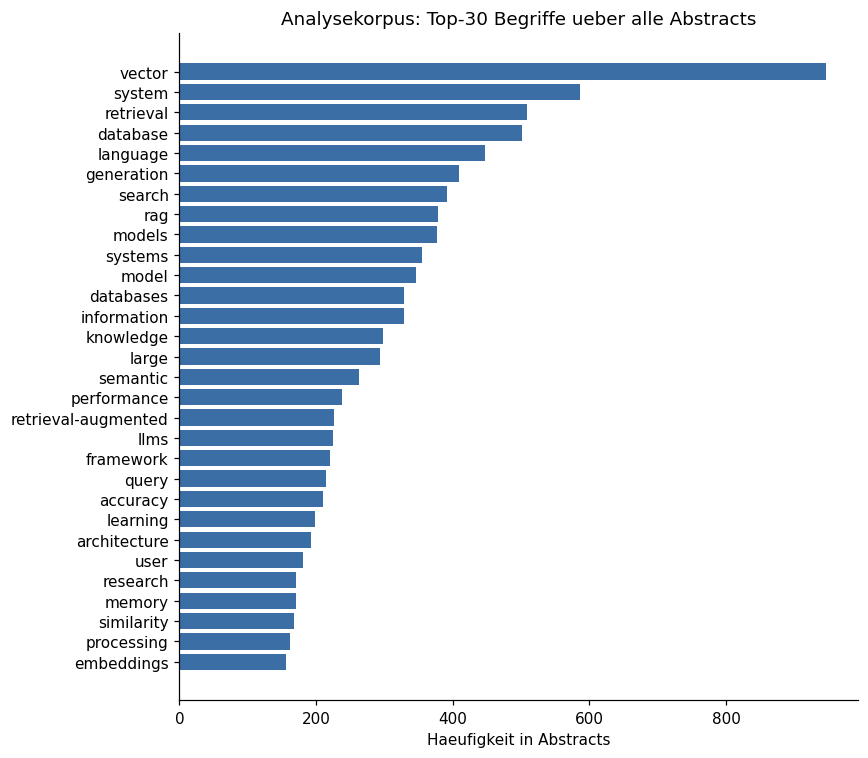

,begriff,anzahl
0,vector,946
1,system,586
2,retrieval,509
3,database,502
4,language,447
5,generation,409
6,search,392
7,rag,379
8,models,377
9,systems,355


In [100]:
overall_counts = Counter()
for text in df_abstracts["abstract_text"]:
    overall_counts.update(clean_tokens(text))

top_terms = pd.DataFrame(overall_counts.most_common(30), columns=["begriff", "anzahl"])

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_terms["begriff"], top_terms["anzahl"], color="#3b6ea5")
ax.invert_yaxis()
ax.set_xlabel("Haeufigkeit in Abstracts")
ax.set_title("Analysekorpus: Top-30 Begriffe ueber alle Abstracts")
plt.tight_layout()
plt.show()

top_terms

### 7.2 Trend ausgewählter Fachbegriffe über die Jahre

**Hinweis:** Die Begriffsliste ist ein Vorschlag und sollte an die tatsächlichen Schwerpunkte
deines Surveys angepasst werden.

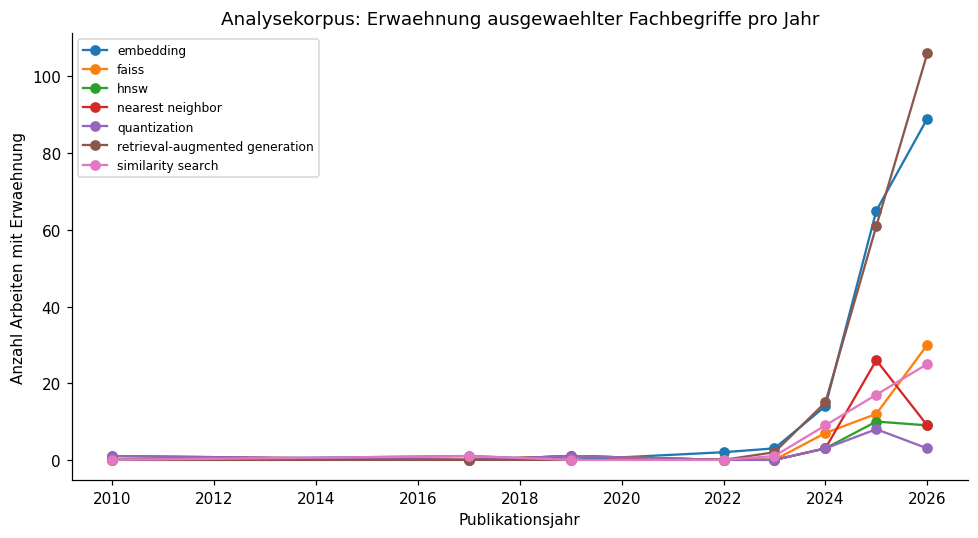

begriff,embedding,faiss,hnsw,nearest neighbor,quantization,retrieval-augmented generation,similarity search
publication_year,,,,,,,
2010.0,0,0,0,1,1,0,0
2017.0,1,0,0,0,0,0,1
2019.0,0,1,1,1,1,0,0
2022.0,2,0,0,0,0,0,0
2023.0,3,0,0,0,0,2,1
2024.0,14,7,3,3,3,15,9
2025.0,65,12,10,26,8,61,17
2026.0,89,30,9,9,3,106,25


In [101]:
fachbegriffe = [
    "hnsw", "faiss", "quantization", "nearest neighbor", "similarity search",
    "embedding", "retrieval-augmented generation",
]

rows = []
for _, row in df_abstracts.iterrows():
    text_lower = row["abstract_text"].lower()
    for begriff in fachbegriffe:
        if begriff in text_lower:
            rows.append({"publication_year": row["publication_year"], "begriff": begriff})

df_terms = pd.DataFrame(rows)
term_year = (df_terms.groupby(["publication_year", "begriff"]).size()
             .unstack(fill_value=0).sort_index()) if not df_terms.empty else pd.DataFrame()

if not term_year.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    for begriff in term_year.columns:
        ax.plot(term_year.index, term_year[begriff], marker="o", label=begriff)
    ax.set_xlabel("Publikationsjahr")
    ax.set_ylabel("Anzahl Arbeiten mit Erwaehnung")
    ax.set_title("Analysekorpus: Erwaehnung ausgewaehlter Fachbegriffe pro Jahr")
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Keine Treffer fuer die angegebenen Fachbegriffe im Analysekorpus.")

term_year

### 7.3 Charakteristische Begriffe der Top-Gap-Themen

Für die Gap-Kandidaten aus Abschnitt 6 (Variable `top_labels`) werden hier die Abstracts der
jeweils zugehörigen Arbeiten (innerhalb des Analysekorpus) geladen und die häufigsten Begriffe
berechnet. Über einen **Lift-Wert** (relative Häufigkeit im Topic geteilt durch relative Häufigkeit
im Gesamtkorpus aus 7.1) werden Begriffe hervorgehoben, die für dieses Topic überdurchschnittlich
charakteristisch sind.

In [102]:
total_overall = sum(overall_counts.values())

def charakteristische_begriffe(topic_name, top_n=8, min_count=2):
    query = """
    WITH primary_topic AS (
        SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id
        FROM work_topic wt
        ORDER BY wt.work_id, wt.score DESC
    )
    SELECT w.abstract_inverted_index
    FROM vektordb_corpus vc
    JOIN primary_topic pt ON pt.work_id = vc.id
    JOIN topic t ON pt.topic_id = t.id
    JOIN work w ON pt.work_id = w.id
    WHERE t.display_name = %(topic_name)s
      AND w.abstract_inverted_index IS NOT NULL;
    """
    df_topic = pd.read_sql(query, conn, params={"topic_name": topic_name})

    counter = Counter()
    for inv in df_topic["abstract_inverted_index"]:
        counter.update(clean_tokens(reconstruct_abstract_py(inv)))
    total_topic = sum(counter.values())
    if total_topic == 0:
        return pd.DataFrame(columns=["topic", "begriff", "anzahl", "lift"])

    rows = []
    for word, cnt in counter.items():
        if cnt < min_count:
            continue
        freq_topic = cnt / total_topic
        freq_overall = overall_counts.get(word, 1) / total_overall
        rows.append((topic_name, word, cnt, round(freq_topic / freq_overall, 2)))

    return (pd.DataFrame(rows, columns=["topic", "begriff", "anzahl", "lift"])
            .sort_values("lift", ascending=False)
            .head(top_n))

alle_charakteristika = pd.concat(
    [charakteristische_begriffe(topic) for topic in top_labels["topic"]],
    ignore_index=True
)
alle_charakteristika

,topic,begriff,anzahl,lift
0,Generative Adversarial Networks and Image Synthesis,visualseek,5,168.26
1,Generative Adversarial Networks and Image Synthesis,fashion,4,168.26
2,Generative Adversarial Networks and Image Synthesis,movie,5,93.48
3,Generative Adversarial Networks and Image Synthesis,script,7,90.60
4,Generative Adversarial Networks and Image Synthesis,scenes,2,84.13
...,...,...,...,...
75,Cybersecurity and Information Systems,igor,5,153.26
76,Cybersecurity and Information Systems,algebra,3,153.26
77,Cybersecurity and Information Systems,generalisation,2,153.26
78,Cybersecurity and Information Systems,optimisation,2,153.26


## 8. Zusammenfassung und nächste Schritte

Aus den obigen Auswertungen lassen sich für den Survey u. a. folgende Bausteine ableiten:

- **Kapitel „Grundlagen/Taxonomie"**: gestützt auf die Subfield/Topic-Verteilung (Abschnitt 2)
- **Kapitel „Zeitliche Entwicklung"**: gestützt auf Publikationstrend und Topic-Jahr-Heatmap
  (Abschnitt 1.1, 2.2)
- **Kapitel „Kernliteratur"**: Ausgangspunkt sind die meistzitierten Arbeiten (Abschnitt 3)
- **Kapitel „Anwendungsbereiche"**: gestützt auf die Cross-Domain-Analyse (Abschnitt 5)
- **Kapitel „Forschungslücken"**: gestützt auf die Quadrantenanalyse und die charakteristischen
  Begriffe der Gap-Themen (Abschnitt 6–7)

Als nächster Schritt empfiehlt es sich, für die identifizierten Gap-Kandidaten gezielt die
vollständigen Abstracts (und ggf. Volltexte) zu lesen und die hier gefundenen charakteristischen
Begriffe als Ausgangspunkt für eine gezielte Literatursuche (z. B. in Google Scholar, ACM DL,
IEEE Xplore) zu nutzen.

In [103]:
conn.close()